In [1]:
import os
import json
import time
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from tqdm.auto import tqdm

from openai import OpenAI
from pydantic import BaseModel, Field
from enum import Enum

plt.rcParams['font.family'] = ['Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

## 获取数据

- [openalex](https://openalex.org/)
- OpenAlex是一个完全免费开放的学术文献数据库，于2022年1月正式上线。由OurResearch在Arcadia的资助下建立，旨在提供全球范围内的学术论文、作者、机构、期刊和主题的全面检索服务。

In [ ]:
def reconstruct_abstract(inverted_index):

    if not inverted_index:
        return None

    words = []

    for word, positions in inverted_index.items():
        for position in positions:
            words.append((position, word))

    words.sort(key=lambda x: x[0])

    return " ".join(word for _, word in words)


def get_openalex_journal(
    journal,
    issn,
    start_date="2016-01-01",
    end_date="2026-08-30",
    per_page=100,
):

    url = ("https://api.openalex.org/works")
    cursor = "*"
    records = []
    session = requests.Session()

    while True:

        params = {
            "filter": (
                f"primary_location.source.issn:{issn},"
                f"from_publication_date:{start_date},"
                f"to_publication_date:{end_date}"
            ),
            "per-page": per_page,
            "cursor": cursor,
        }

        response = session.get(url,params=params,timeout=60)
        response.raise_for_status()
        data = response.json()

        results = data.get("results",[])

        if not results:
            break

        for item in results:

            # Abstract
            abstract = reconstruct_abstract(item.get("abstract_inverted_index"))

            # Authors
            authors = []
            for authorship in item.get("authorships",[]):
                author = authorship.get("author", {})
                name = author.get("display_name")
                if name:
                    authors.append(name)

            # Date
            publication_date = item.get("publication_date")
            year = int(publication_date[:4]) if publication_date else None

            # DOI
            doi = item.get("doi" )

            # Record
            records.append({
                "journal": journal,
                "title": item.get("title"),
                "abstract": abstract,
                "doi": doi,
                "authors": "; ".join(authors),
                "publication_date":publication_date,
                "year": year,
                "type": item.get("type"),
                "cited_by_count": item.get("cited_by_count"),
                "openalex_id": item.get("id"),
                "url": item.get("id"),
            })


        # Progress
        print(
            f"{journal}: "
            f"{len(records):,} records"
        )

        # Next cursor
        cursor = data["meta"].get("next_cursor")

        if not cursor:
            break

        time.sleep(0.2)

    session.close()

    return pd.DataFrame(records)

In [12]:
nature = get_openalex_journal(
    journal="Nature",
    issn="0028-0836",
)

Nature: 100 records
Nature: 200 records
Nature: 300 records
Nature: 400 records
Nature: 500 records
Nature: 600 records
Nature: 700 records
Nature: 800 records
Nature: 900 records
Nature: 1,000 records
Nature: 1,100 records
Nature: 1,200 records
Nature: 1,300 records
Nature: 1,400 records
Nature: 1,500 records
Nature: 1,600 records
Nature: 1,700 records
Nature: 1,800 records
Nature: 1,900 records
Nature: 2,000 records
Nature: 2,100 records
Nature: 2,200 records
Nature: 2,300 records
Nature: 2,400 records
Nature: 2,500 records
Nature: 2,600 records
Nature: 2,700 records
Nature: 2,800 records
Nature: 2,900 records
Nature: 3,000 records
Nature: 3,100 records
Nature: 3,200 records
Nature: 3,300 records
Nature: 3,400 records
Nature: 3,500 records
Nature: 3,600 records
Nature: 3,700 records
Nature: 3,800 records
Nature: 3,900 records
Nature: 4,000 records
Nature: 4,100 records
Nature: 4,200 records
Nature: 4,300 records
Nature: 4,400 records
Nature: 4,500 records
Nature: 4,600 records
Nature

In [13]:
science = get_openalex_journal(
    journal="Science",
    issn="0036-8075",
)

Science: 100 records
Science: 200 records
Science: 300 records
Science: 400 records
Science: 500 records
Science: 600 records
Science: 700 records
Science: 800 records
Science: 900 records
Science: 1,000 records
Science: 1,100 records
Science: 1,200 records
Science: 1,300 records
Science: 1,400 records
Science: 1,500 records
Science: 1,600 records
Science: 1,700 records
Science: 1,800 records
Science: 1,900 records
Science: 2,000 records
Science: 2,100 records
Science: 2,200 records
Science: 2,300 records
Science: 2,400 records
Science: 2,500 records
Science: 2,600 records
Science: 2,700 records
Science: 2,800 records
Science: 2,900 records
Science: 3,000 records
Science: 3,100 records
Science: 3,200 records
Science: 3,300 records
Science: 3,400 records
Science: 3,500 records
Science: 3,600 records
Science: 3,700 records
Science: 3,800 records
Science: 3,900 records
Science: 4,000 records
Science: 4,100 records
Science: 4,200 records
Science: 4,300 records
Science: 4,400 records
Scienc

In [24]:
(
    pd
    .concat([
        nature.query("type=='article'").sort_values("publication_date"),
        science.query("type=='article'").sort_values("publication_date")
    ])
    .reset_index(drop=True)
    .to_excel("data/ns_article_2016to2026.xlsx", index=False)
)

## 文章标题情感分析

In [53]:
df = pd.read_excel("data/ns_article_2016to2026.xlsx")
df

,journal,title,abstract,doi,authors,publication_date,year,type,cited_by_count,openalex_id,url
0,Nature,Influence of extreme weather disasters on glob...,NaN,https://doi.org/10.1038/nature16467,Corey Lesk; Pedram Rowhani; Navin Ramankutty,2016-01-01,2016,article,3848,https://openalex.org/W2227280755,https://openalex.org/W2227280755
1,Nature,Antibacterial drug discovery in the resistance...,NaN,https://doi.org/10.1038/nature17042,Eric D. Brown; Gerard D. Wright,2016-01-01,2016,article,2273,https://openalex.org/W2300011769,https://openalex.org/W2300011769
2,Nature,Metastatic colonization by circulating tumour ...,NaN,https://doi.org/10.1038/nature17038,Joan Massagué; Anna C. Obenauf,2016-01-01,2016,article,2081,https://openalex.org/W2266814182,https://openalex.org/W2266814182
3,Nature,Partially oxidized atomic cobalt layers for ca...,NaN,https://doi.org/10.1038/nature16455,Shan Gao; Yue Lin; Xingchen Jiao; Yongfu Sun; ...,2016-01-01,2016,article,1866,https://openalex.org/W2227974961,https://openalex.org/W2227974961
4,Nature,Protein misfolding in the endoplasmic reticulu...,NaN,https://doi.org/10.1038/nature17041,Miao Wang; Randal J. Kaufman,2016-01-01,2016,article,1662,https://openalex.org/W2263498456,https://openalex.org/W2263498456
...,...,...,...,...,...,...,...,...,...,...,...
71714,Science,Orbital alchemy,Maturing space labs and cheaper launches fuel ...,https://doi.org/10.1126/science.ael8347,Michael Greshko,2026-08-27,2026,article,0,https://openalex.org/W7204480146,https://openalex.org/W7204480146
71715,Science,Deep-sea mining outpaces both science and law,NaN,https://doi.org/10.1126/science.aek5038,Alejandro Olivera; Erick Morales-Montes de Oca...,2026-08-27,2026,article,0,https://openalex.org/W7204489874,https://openalex.org/W7204489874
71716,Science,Correcting the logic behind the 2026 US vehicl...,Correction of selective assumptions and incons...,https://doi.org/10.1126/science.aef0464,Antonio M. Bento; Kenneth T. Gillingham; Mark ...,2026-08-27,2026,article,0,https://openalex.org/W7204491543,https://openalex.org/W7204491543
71717,Science,Desert flooding highlights a critical gap in c...,NaN,https://doi.org/10.1126/science.aek8173,Ji-Xi Gao; Hai-Dong Li; Li-Jun Zhao; Dilinuer ...,2026-08-27,2026,article,0,https://openalex.org/W7204492628,https://openalex.org/W7204492628


In [ ]:
CHN = df[df["title"].str.contains("China|CHINA")]  # 提取包含中国的文章
USA = df[df["title"].str.contains("USA|United States|U.S.")]  # 提取包含美国的文章

print(
    f"CHN: {len(CHN)}\n"
    f"USA: {len(USA)}"
)

CHN: 772
USA: 662


In [68]:
# 合并
CHN["country"] = "China"
USA["country"] = "United States"

df0 = pd.concat([CHN, USA], ignore_index=True)
df0["FID"] = range(len(df0))
df0

,journal,title,abstract,doi,authors,publication_date,year,type,cited_by_count,openalex_id,url,country,FID
0,Nature,Sustainable Hydropower Developments for China,NaN,NaN,Weiyao Tang; Wei Shen; Lei Zhu; Sen Wang; Coli...,2016-01-01,2016,article,0,https://openalex.org/W3006023338,https://openalex.org/W3006023338,China,0
1,Nature,China boom leaves children behind,NaN,https://doi.org/10.1038/529025a,Peng Yuan; Long Wang,2016-01-06,2016,article,46,https://openalex.org/W2222969088,https://openalex.org/W2222969088,China,1
2,Nature,China’s quantum space pioneer: We need to expl...,NaN,https://doi.org/10.1038/nature.2016.19166,Celeste Biever,2016-01-13,2016,article,6,https://openalex.org/W2516365309,https://openalex.org/W2516365309,China,2
3,Nature,The contribution of China’s emissions to globa...,NaN,https://doi.org/10.1038/nature17165,Bengang Li; Thomas Gasser; Philippe Ciais; Shi...,2016-03-01,2016,article,307,https://openalex.org/W2300402820,https://openalex.org/W2300402820,China,3
4,Nature,China’s contribution to climate change,NaN,https://doi.org/10.1038/531310a,Dominick V. Spracklen,2016-03-01,2016,article,30,https://openalex.org/W2301582879,https://openalex.org/W2301582879,China,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,Science,U.S. agencies join fight against ‘ultraprocess...,Some scientists criticize label as imprecise; ...,https://doi.org/10.1126/science.aej5920,Dan Charles,2026-06-11,2026,article,0,https://openalex.org/W7164368145,https://openalex.org/W7164368145,United States,1429
1430,Science,Researchers caught in the crossfire as firms a...,Tumultuous Fable 5 takedown spurs fears for op...,https://doi.org/10.1126/science.aej9813,Celina Zhao,2026-06-25,2026,article,0,https://openalex.org/W7165928831,https://openalex.org/W7165928831,United States,1430
1431,Science,U.S. researchers express outrage over proposed...,"White House receives 340,000 comments on rules...",https://doi.org/10.1126/science.aek5959,Jeffrey Mervis,2026-07-16,2026,article,0,https://openalex.org/W7169198663,https://openalex.org/W7169198663,United States,1431
1432,Science,Detention of U.S. seismologist by China alarms...,Youlin Chen analyzed earthquake data that can ...,https://doi.org/10.1126/science.aek8033,Richard Stone,2026-07-23,2026,article,0,https://openalex.org/W7170182154,https://openalex.org/W7170182154,United States,1432


In [ ]:
api_key = os.environ["DEEPSEEK_API_KEY"]

client = OpenAI(
    api_key=api_key,
    base_url="https://api.deepseek.com",
)

class SentimentLabel(str, Enum):
    positive = "positive"
    negative = "negative"
    neutral = "neutral"

class SentimentResult(BaseModel):
    sentiment: SentimentLabel = Field(
        description="情感类别"
    )

    score: float = Field(
        ge=0.0,
        le=1.0,
        description="情感分类置信度"
    )

def sentiment_analysis(text: str) -> SentimentResult:

    system_prompt = """
        你是一个专业的英文文本情感分析模型。
        请分析用户提供的英文文章标题，并判断其情感。
        情感类别只能选择：
        positive：正面情感
        negative：负面情感
        neutral：中性情感
        score：分类结果的置信度，
        取值范围必须为 0 到 1。
        请严格输出 JSON，格式：
        {
            "sentiment": "positive",
            "score": 0.95
        }
        不要输出任何额外文字。
    """

    response = client.chat.completions.create(
        model="deepseek-v4-flash",
        messages=[
            {
                "role": "system",
                "content": system_prompt,
            },
            {
                "role": "user",
                "content": str(text),
            },
        ],
        response_format={
            "type": "json_object"
        },
        temperature=0,
    )

    content = response.choices[0].message.content
    if not content:
        raise ValueError(
            f"DeepSeek returned empty content. "
            f"response={response}"
        )
    content = content.strip()

    try:
        data = json.loads(content)
    except json.JSONDecodeError as e:

        print("\nJSON 解析失败")
        print("原始返回：")
        print(repr(content))

        raise e

    return SentimentResult.model_validate(data)

In [73]:
text = "Orbital alchemy"
result = sentiment_analysis(text)
print(result)

sentiment=<SentimentLabel.neutral: 'neutral'> score=0.8


In [74]:
print(result.sentiment.value)
print(result.score)

neutral
0.8


In [75]:
def safe_sentiment_analysis(text):

    try:
        result = sentiment_analysis(text)

        return {
            "sentiment": result.sentiment.value,
            "score": result.score
        }

    except Exception as e:

        print(f"\n处理失败: {text}")
        print(f"错误: {e}")

        return {
            "sentiment": None,
            "score": None
        }

In [76]:
tqdm.pandas(desc="Sentiment Analysis")

result = df0["title"].progress_apply(safe_sentiment_analysis)
df0[["sentiment", "score"]] = result.apply(pd.Series)

Sentiment Analysis:   0%|          | 0/1434 [00:00<?, ?it/s]

In [77]:
df0

,journal,title,abstract,doi,authors,publication_date,year,type,cited_by_count,openalex_id,url,country,FID,sentiment,score
0,Nature,Sustainable Hydropower Developments for China,NaN,NaN,Weiyao Tang; Wei Shen; Lei Zhu; Sen Wang; Coli...,2016-01-01,2016,article,0,https://openalex.org/W3006023338,https://openalex.org/W3006023338,China,0,positive,0.90
1,Nature,China boom leaves children behind,NaN,https://doi.org/10.1038/529025a,Peng Yuan; Long Wang,2016-01-06,2016,article,46,https://openalex.org/W2222969088,https://openalex.org/W2222969088,China,1,negative,0.90
2,Nature,China’s quantum space pioneer: We need to expl...,NaN,https://doi.org/10.1038/nature.2016.19166,Celeste Biever,2016-01-13,2016,article,6,https://openalex.org/W2516365309,https://openalex.org/W2516365309,China,2,positive,0.90
3,Nature,The contribution of China’s emissions to globa...,NaN,https://doi.org/10.1038/nature17165,Bengang Li; Thomas Gasser; Philippe Ciais; Shi...,2016-03-01,2016,article,307,https://openalex.org/W2300402820,https://openalex.org/W2300402820,China,3,neutral,0.90
4,Nature,China’s contribution to climate change,NaN,https://doi.org/10.1038/531310a,Dominick V. Spracklen,2016-03-01,2016,article,30,https://openalex.org/W2301582879,https://openalex.org/W2301582879,China,4,neutral,0.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,Science,U.S. agencies join fight against ‘ultraprocess...,Some scientists criticize label as imprecise; ...,https://doi.org/10.1126/science.aej5920,Dan Charles,2026-06-11,2026,article,0,https://openalex.org/W7164368145,https://openalex.org/W7164368145,United States,1429,positive,0.90
1430,Science,Researchers caught in the crossfire as firms a...,Tumultuous Fable 5 takedown spurs fears for op...,https://doi.org/10.1126/science.aej9813,Celina Zhao,2026-06-25,2026,article,0,https://openalex.org/W7165928831,https://openalex.org/W7165928831,United States,1430,negative,0.85
1431,Science,U.S. researchers express outrage over proposed...,"White House receives 340,000 comments on rules...",https://doi.org/10.1126/science.aek5959,Jeffrey Mervis,2026-07-16,2026,article,0,https://openalex.org/W7169198663,https://openalex.org/W7169198663,United States,1431,negative,0.95
1432,Science,Detention of U.S. seismologist by China alarms...,Youlin Chen analyzed earthquake data that can ...,https://doi.org/10.1126/science.aek8033,Richard Stone,2026-07-23,2026,article,0,https://openalex.org/W7170182154,https://openalex.org/W7170182154,United States,1432,negative,0.95


In [78]:
df0.to_csv("data/ns_chn_usa_sentiment.csv", index=False)

## 可视化

In [2]:
df = pd.read_csv(
    "data/ns_chn_usa_sentiment.csv",
    usecols=[
        "journal",
        "title",
        "publication_date",
        "country",
        "sentiment",
        "score"
    ]
)
df

,journal,title,publication_date,country,sentiment,score
0,Nature,Sustainable Hydropower Developments for China,2016-01-01,China,positive,0.90
1,Nature,China boom leaves children behind,2016-01-06,China,negative,0.90
2,Nature,China’s quantum space pioneer: We need to expl...,2016-01-13,China,positive,0.90
3,Nature,The contribution of China’s emissions to globa...,2016-03-01,China,neutral,0.90
4,Nature,China’s contribution to climate change,2016-03-01,China,neutral,0.90
...,...,...,...,...,...,...
1429,Science,U.S. agencies join fight against ‘ultraprocess...,2026-06-11,United States,positive,0.90
1430,Science,Researchers caught in the crossfire as firms a...,2026-06-25,United States,negative,0.85
1431,Science,U.S. researchers express outrage over proposed...,2026-07-16,United States,negative,0.95
1432,Science,Detention of U.S. seismologist by China alarms...,2026-07-23,United States,negative,0.95


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1434 entries, 0 to 1433
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   journal           1434 non-null   str    
 1   title             1434 non-null   str    
 2   publication_date  1434 non-null   str    
 3   country           1434 non-null   str    
 4   sentiment         1434 non-null   str    
 5   score             1434 non-null   float64
dtypes: float64(1), str(5)
memory usage: 201.3 KB


In [4]:
# 处理时间
df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)
df["year"] = df["publication_date"].dt.year

<Axes: xlabel='sentiment'>

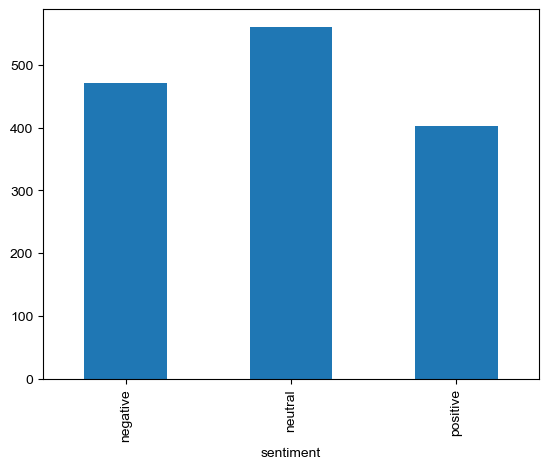

In [5]:
df.groupby("sentiment").size().plot(kind="bar")

In [6]:
# 计算每个 group 的总数，用于计算百分比
grouped = df.groupby(['journal', 'year', 'country', 'sentiment']).size().reset_index(name='count')
grouped['total'] = grouped.groupby(['journal', 'year', 'country'])['count'].transform('sum')
grouped['percentage'] = grouped['count'] / grouped['total'] * 100
grouped['country_sentiment'] = grouped['country'] + '-' + grouped['sentiment']  # 创建组合列用于 hue（国家和情感的组合）
grouped

,journal,year,country,sentiment,count,total,percentage,country_sentiment
0,Nature,2016,China,negative,3,37,8.108108,China-negative
1,Nature,2016,China,neutral,19,37,51.351351,China-neutral
2,Nature,2016,China,positive,15,37,40.540541,China-positive
3,Nature,2016,United States,neutral,1,2,50.000000,United States-neutral
4,Nature,2016,United States,positive,1,2,50.000000,United States-positive
...,...,...,...,...,...,...,...,...
121,Science,2026,China,neutral,7,16,43.750000,China-neutral
122,Science,2026,China,positive,2,16,12.500000,China-positive
123,Science,2026,United States,negative,12,18,66.666667,United States-negative
124,Science,2026,United States,neutral,5,18,27.777778,United States-neutral


In [7]:
# 配色
color_map = {
    "negative": "#2E4A6E",
    "neutral": "#6B85A3",
    "positive": "#A8C4D8",
}
us_color_map = {
    "negative": "#1A2F4A",
    "neutral": "#4A6480",
    "positive": "#8EA3BF",
}

sentiment_map = {
    "positive": "正面",
    "neutral": "中性",
    "negative": "负面",
}

### 堆叠图

In [8]:
def plot_journal(ax, df, title):
    # 透视：year × sentiment，value=percentage，分别取出 China / US
    pivot_cn = df[df["country"]=="China"].pivot(index="year", columns="sentiment", values="percentage").fillna(0)
    pivot_us = df[df["country"]=="United States"].pivot(index="year", columns="sentiment", values="percentage").fillna(0)
    # 保证列顺序统一 negative, neutral, positive
    cols = ["negative", "neutral", "positive"]
    pivot_cn = pivot_cn.reindex(columns=cols, fill_value=0)
    pivot_us = pivot_us.reindex(columns=cols, fill_value=0)

    years = pivot_cn.index.union(pivot_us.index).sort_values()
    bar_width = 0.35
    x = np.arange(len(years))

    # 绘制中国堆叠
    bottom_cn = np.zeros(len(years))
    for s in cols:
        vals = pivot_cn.reindex(years)[s].values
        ax.bar(x - bar_width/2, vals, bar_width, bottom=bottom_cn, color=color_map[s], label=f"China - {sentiment_map.get(s, s)}")
        bottom_cn += vals

    # 绘制美国堆叠
    bottom_us = np.zeros(len(years))
    for s in cols:
        vals = pivot_us.reindex(years)[s].values
        ax.bar(x + bar_width/2, vals, bar_width, bottom=bottom_us, color=us_color_map[s], label=f"U.S. - {sentiment_map.get(s, s)}")
        bottom_us += vals

    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=12)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel("Percentage (%)", fontsize=14)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0,105) # 百分比上限
    # 关闭子图自身图例
    if ax.get_legend():
            ax.get_legend().remove()

In [9]:
# 筛选期刊
df_nature = grouped[grouped["journal"] == "Nature"].copy()
df_science = grouped[grouped["journal"] == "Science"].copy()

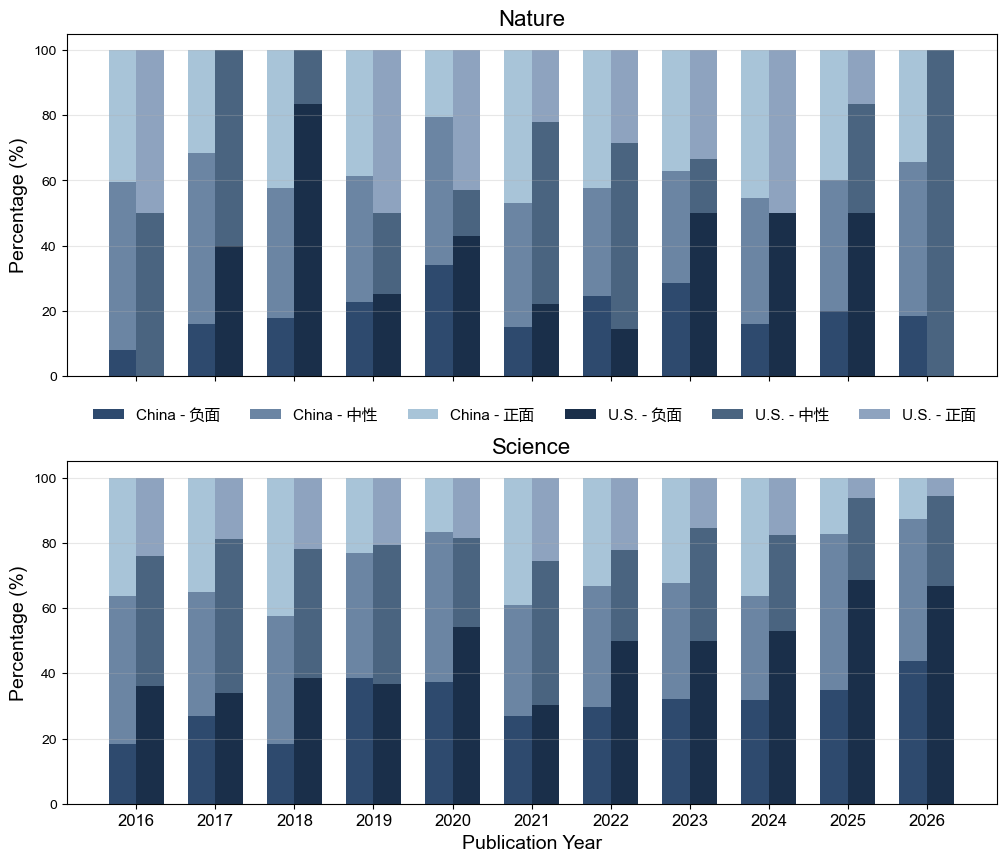

In [10]:
# 画布：上下子图，上图Nature，下图Science，共享x轴
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12, 10), sharex=True)

plot_journal(ax1, df_nature, "Nature")
plot_journal(ax2, df_science, "Science")

ax2.set_xlabel("Publication Year", fontsize=14)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.515, 0.52),  # 图例位置
    ncol=6,
    frameon=False,
    fontsize=11
)

plt.subplots_adjust(hspace=0.25)  # 子图上下间隔
plt.savefig("堆叠.png", dpi=500, bbox_inches="tight")
plt.show()

### 词云图

In [11]:
df

,journal,title,publication_date,country,sentiment,score,year
0,Nature,Sustainable Hydropower Developments for China,2016-01-01,China,positive,0.90,2016
1,Nature,China boom leaves children behind,2016-01-06,China,negative,0.90,2016
2,Nature,China’s quantum space pioneer: We need to expl...,2016-01-13,China,positive,0.90,2016
3,Nature,The contribution of China’s emissions to globa...,2016-03-01,China,neutral,0.90,2016
4,Nature,China’s contribution to climate change,2016-03-01,China,neutral,0.90,2016
...,...,...,...,...,...,...,...
1429,Science,U.S. agencies join fight against ‘ultraprocess...,2026-06-11,United States,positive,0.90,2026
1430,Science,Researchers caught in the crossfire as firms a...,2026-06-25,United States,negative,0.85,2026
1431,Science,U.S. researchers express outrage over proposed...,2026-07-16,United States,negative,0.95,2026
1432,Science,Detention of U.S. seismologist by China alarms...,2026-07-23,United States,negative,0.95,2026


In [12]:
stopwords = STOPWORDS.union({
    "the","of","and","in","to","a","is","for","on","with","by",
    "this","that","as","we","our","it","be","are","was","have","has",
})

# China‑Nature negative
df_cn_nat = df[(df["journal"]=="Nature") & (df["sentiment"]=="negative") & (df["country"]=="China")]
text_cn_nat = " ".join(df_cn_nat["title"].dropna().astype(str).tolist())

# China‑Science negative
df_cn_sci = df[(df["journal"]=="Science") & (df["sentiment"]=="negative") & (df["country"]=="China")]
text_cn_sci = " ".join(df_cn_sci["title"].dropna().astype(str).tolist())

# US‑Nature negative
df_us_nat = df[(df["journal"]=="Nature") & (df["sentiment"]=="negative") & (df["country"]=="United States")]
text_us_nat = " ".join(df_us_nat["title"].dropna().astype(str).tolist())

# US‑Science negative
df_us_sci = df[(df["journal"]=="Science") & (df["sentiment"]=="negative") & (df["country"]=="United States")]
text_us_sci = " ".join(df_us_sci["title"].dropna().astype(str).tolist())

In [13]:
wc_params = {
    "background_color":"white",
    "width":1400,
    "height":1000,
    "max_words":100,
    "stopwords": stopwords,
    "colormap":"Blues"
}

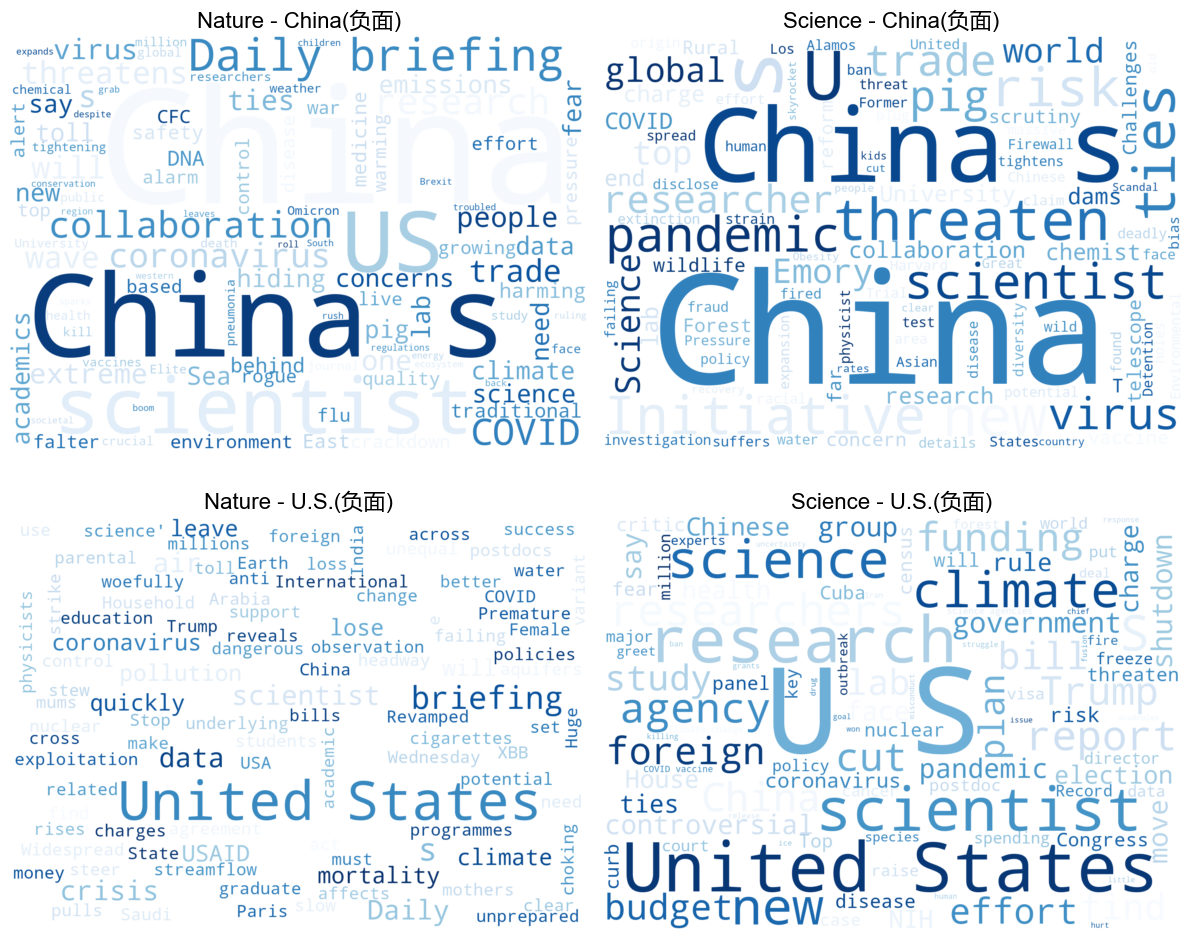

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax_cn_nat, ax_cn_sci = axes[0]
ax_us_nat, ax_us_sci = axes[1]

# 第一行：中国
wc_cn_nat = WordCloud(**wc_params).generate(text_cn_nat)
ax_cn_nat.imshow(wc_cn_nat, interpolation="bilinear")
ax_cn_nat.set_title("Nature - China(负面)", fontsize=16)
ax_cn_nat.axis("off")

wc_cn_sci = WordCloud(**wc_params).generate(text_cn_sci)
ax_cn_sci.imshow(wc_cn_sci, interpolation="bilinear")
ax_cn_sci.set_title("Science - China(负面)", fontsize=16)
ax_cn_sci.axis("off")

# 第二行：美国
wc_us_nat = WordCloud(**wc_params).generate(text_us_nat)
ax_us_nat.imshow(wc_us_nat, interpolation="bilinear")
ax_us_nat.set_title("Nature - U.S.(负面)", fontsize=16)
ax_us_nat.axis("off")

wc_us_sci = WordCloud(**wc_params).generate(text_us_sci)
ax_us_sci.imshow(wc_us_sci, interpolation="bilinear")
ax_us_sci.set_title("Science - U.S.(负面)", fontsize=16)
ax_us_sci.axis("off")

# 调整子图间距
plt.tight_layout()
plt.savefig("词云.png", dpi=500, bbox_inches="tight")
plt.show()